<a href="https://colab.research.google.com/github/kny1209/test2/blob/main/AI/%EA%B0%95%EC%9D%98_8%EA%B8%B0_AI%EA%B0%9C%EB%A1%A0_10%EC%B0%A8%EC%8B%9C_02_%ED%8F%89%EA%B0%80%EC%A7%80%ED%91%9C_%EB%B0%8F_%ED%81%B4%EB%9E%98%EC%8A%A4%EB%B6%88%EA%B7%A0%ED%98%95%EC%B2%98%EB%A6%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
!sudo apt-get install -y fonts-nanum* | tail -n 1
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

0 upgraded, 0 newly installed, 0 to remove and 6 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped directory detected
/var/cache/fontconfig: cleaning cache directory
/root/.cache/fontconfig: not cleaning non-existent cache direct

In [18]:
# 라이브러리 임포트


%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display


# 폰트 관련 용도
import matplotlib.font_manager as fm


# 나눔 고딕 폰트의 경로 명시
path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=path, size=10).get_name()

In [19]:
# 기본 설정값 변경


# 기본 폰트 설정
plt.rcParams['font.family'] = font_name


# 기본 폰트 사이즈 변경
# 필요에 따라 설정할 때는, plt.legend(fontsize=14)
plt.rcParams['font.size'] = 14


# 기본 그래프 사이즈 변경
# 필요에 따라 설정할 때는, plt.figure(figsize=(6,6))
plt.rcParams['figure.figsize'] = (6,6)


# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True


# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

In [20]:
import numpy as np

np.eye(20)

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0.

In [21]:
"""
10차수: 고급 평가지표 및 클래스 불균형 처리
- 혼동행렬 해석
- Precision, Recall, F1 (클래스별/마이크로/매크로)
- ROC-AUC (One-vs-Rest)
- Calibration & 온도 스케일링
- 클래스 불균형 처리
"""


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc,
    precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize
from collections import Counter


# 재현성 설정
torch.manual_seed(42)
np.random.seed(42)

In [22]:
# 불균형 데이터 셋

class ImbalancedDataset(Dataset):
    def __init__(self, n_samples=2000, n_features=20, n_classes=4,
                 imbalance_ratio=[0.5, 0.3, 0.15, 0.05]):
        self.n_classes = n_classes
        samples_per_class = [int(n_samples * ratio) for ratio in imbalance_ratio]


        X_list = []
        y_list = []


        for class_idx in range(n_classes):
            n = samples_per_class[class_idx]
            mean = np.random.randn(n_features) * (class_idx + 1)
            # 평균 재정의 : 평균을 class_idx 비례하게 설정 >> 클래스 간 거리 두게 됨
            cov = np.eye(n_features) * (0.5 + class_idx * 0.2)
            # 공분산(cov) 조절 >> 데이터 퍼진 정도 (분산) 클래스 별로 다르게 하려고 조작한 것
            X_class = np.random.multivariate_normal(mean, cov, n)
            y_class = np.full(n, class_idx)


            X_list.append(X_class)
            y_list.append(y_class)


        self.X = torch.FloatTensor(np.vstack(X_list)) # featrue matrix
        self.y = torch.LongTensor(np.hstack(y_list))  # target vector


        class_counts = Counter(self.y.numpy())
        print(f"\n전체 클래스 분포: {dict(sorted(class_counts.items()))}")


    def __len__(self):
        return len(self.X)


    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [23]:
# 모델 정의

class MultiClassClassifier(nn.Module):
    def __init__(self, input_dim=20, hidden_dim=64, n_classes=4):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, n_classes)
        )


    def forward(self, x):
        return self.network(x)

In [24]:
# ===================================================================
# 3. 온도 스케일링
# ===================================================================
class TemperatureScaling(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)
        # 과신을 완화시키는 역할
        # logits(모델이 예측) >> softmax 확률 변환하는데...
        # 확률 변환 전에 T로 나눠서 확률분포를 완화(smoothing)하는 작업을 수행하게 함
        # 여기서 T=1 (원래 모델과 동일) / T>1 확률분포가 완만해지기 때문에 >> 과신 현상 완화


    def forward(self, logits):
        return logits / self.temperature


    def calibrate(self, model, val_loader, device, max_iter=50):
        nll_criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.LBFGS([self.temperature], lr=0.01, max_iter=max_iter)
        # 1차 미분 : gradient(경사) 순간 변화률 (특정 지점의 기울기)
        # >> 어느 방향으로 가야하나?
        # 2차 미분 : 기울기(경사) 의 변화량
        # >> (여기서부터) 얼마나 급격히 변하나? (가속도)
        # (곡률: 곡선이 얼마나 구부려져 있는가)
        # 왜 이걸 굳이 썼을까?
        # 2차 미분 하면 스칼라 값 >> 최적화해야 할 변수는 단 하나 temperature
        # LBFGS (Limited Memory Broyden Fletcher Goldfarb Shanno optimization
        # 2차 최적화 알고리즘 : 뉴턴 방법(1차 미분과 2차 미분(곡률) 동시 적용 최소값 찾는 방법)의 근사 형태 (근사치)
        # >> 이전 단계 변화량을 사용, 헤시안(Hessian) 근사치
        # >> 실제 수치해석에 들어가는 헤시안을 직접 구하지 않고 점진적으로 업데이트 나가서 근사치 구한다
        # >> 최근 10단계 업데이트된 정보만 저장해서 근사치를 구함 >> 제한된 메모리 사용
        # (일반적으로 딥러닝에 사용하는 Adam, SGD 1차 미분: gradient)


        logits_list = []
        labels_list = []


        model.eval()
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                logits = model(inputs)
                logits_list.append(logits)
                labels_list.append(labels)


        logits = torch.cat(logits_list)
        labels = torch.cat(labels_list)


        def eval_loss():
            optimizer.zero_grad()
            loss = nll_criterion(self.forward(logits), labels)
            loss.backward()
            return loss


        optimizer.step(eval_loss)


        print(f"온도 스케일링 완료: T = {self.temperature.item():.3f}")
        return self.temperature.item()

In [25]:
# ===================================================================
# 4. 혼동행렬 시각화
# ===================================================================
def plot_confusion_matrix_with_analysis(y_true, y_pred, class_names):
    cm = confusion_matrix(y_true, y_pred)


    fig, axes = plt.subplots(1, 2, figsize=(15, 5))


    # 혼동행렬
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=axes[0])
    axes[0].set_title('혼동행렬 (Confusion Matrix)', fontsize=14, pad=10)
    axes[0].set_ylabel('실제 클래스', fontsize=11)
    axes[0].set_xlabel('예측 클래스', fontsize=11)


    # 오류 분석(데이터 정규화)
    # .sum(axis=1) 각 행의 합 >> 해당 클래스 중 몇 퍼센트가 틀렸는지 계산하기 위해
    # 클래스의 데이터가 불균형할 때 필수
    # + 1e-10 zero division 방지용
    cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)


    error_analysis = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j and cm[i, j] > 0:
                error_analysis.append({
                    'True': class_names[i],
                    'Pred': class_names[j],
                    'Count': cm[i, j],
                    'Rate': cm_normalized[i, j]
                })


    if len(error_analysis) > 0:
        error_analysis.sort(key=lambda x: x['Rate'], reverse=True)
        # x['Rate'](cm_normalized[i, j]) 기준, 내림차순
        top_errors = error_analysis[:min(5, len(error_analysis))]
        error_labels = [f"{e['True']}→{e['Pred']}" for e in top_errors]
        error_rates = [e['Rate'] * 100 for e in top_errors]


        axes[1].barh(error_labels, error_rates, color='coral')
        axes[1].set_xlabel('오류율 (%)', fontsize=11)
        axes[1].set_title('주요 오류 유형', fontsize=14, pad=10)
        axes[1].grid(axis='x', alpha=0.3)
    else:
        axes[1].text(0.5, 0.5, '완벽한 분류!',
                    transform=axes[1].transAxes, ha='center', va='center',
                    fontsize=16)
        axes[1].axis('off')


    plt.tight_layout()
    plt.show()


    return cm

In [26]:
# ===================================================================
# 5. 상세 평가지표
# ===================================================================
def calculate_detailed_metrics(y_true, y_pred, y_proba, class_names):
    precision, recall, f1, support = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0
    )


    metrics_avg = {
        'macro': precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)[:3],
        'micro': precision_recall_fscore_support(y_true, y_pred, average='micro', zero_division=0)[:3],
        'weighted': precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)[:3]
    }


    fig, axes = plt.subplots(2, 2, figsize=(15, 10))


    # (1) 클래스별 지표
    x = np.arange(len(class_names))
    width = 0.25


    axes[0, 0].bar(x - width, precision, width, label='Precision', alpha=0.8)
    axes[0, 0].bar(x, recall, width, label='Recall', alpha=0.8)
    axes[0, 0].bar(x + width, f1, width, label='F1-Score', alpha=0.8)
    axes[0, 0].set_xlabel('클래스', fontsize=11)
    axes[0, 0].set_ylabel('점수', fontsize=11)
    axes[0, 0].set_title('클래스별 평가지표', fontsize=13, pad=10)
    axes[0, 0].set_xticks(x)
    axes[0, 0].set_xticklabels(class_names)
    axes[0, 0].legend()
    axes[0, 0].grid(axis='y', alpha=0.3)
    axes[0, 0].set_ylim([0, 1.1])


    # (2) 평균 방식 비교
    avg_types = ['Macro', 'Micro', 'Weighted']
    avg_precisions = [metrics_avg['macro'][0], metrics_avg['micro'][0], metrics_avg['weighted'][0]]
    avg_recalls = [metrics_avg['macro'][1], metrics_avg['micro'][1], metrics_avg['weighted'][1]]
    avg_f1s = [metrics_avg['macro'][2], metrics_avg['micro'][2], metrics_avg['weighted'][2]]


    x_avg = np.arange(len(avg_types))
    axes[0, 1].bar(x_avg - width, avg_precisions, width, label='Precision', alpha=0.8)
    axes[0, 1].bar(x_avg, avg_recalls, width, label='Recall', alpha=0.8)
    axes[0, 1].bar(x_avg + width, avg_f1s, width, label='F1-Score', alpha=0.8)
    axes[0, 1].set_xlabel('평균 방식', fontsize=11)
    axes[0, 1].set_ylabel('점수', fontsize=11)
    axes[0, 1].set_title('평균 방식별 비교', fontsize=13, pad=10)
    axes[0, 1].set_xticks(x_avg)
    axes[0, 1].set_xticklabels(avg_types)
    axes[0, 1].legend()
    axes[0, 1].grid(axis='y', alpha=0.3)
    axes[0, 1].set_ylim([0, 1.1])


    # (3) Support vs F1
    axes[1, 0].scatter(support, f1, s=100, alpha=0.6, c=range(len(class_names)), cmap='viridis')
    for i, name in enumerate(class_names):
        axes[1, 0].annotate(name, (support[i], f1[i]),
                           xytext=(5, 5), textcoords='offset points', fontsize=9)
    axes[1, 0].set_xlabel('샘플 수', fontsize=11)
    axes[1, 0].set_ylabel('F1-Score', fontsize=11)
    axes[1, 0].set_title('클래스 불균형과 성능', fontsize=13, pad=10)
    axes[1, 0].grid(alpha=0.3)


    # (4) 설명
    explanation = (
        "평균 방식:\n\n"
        "• Macro: 클래스별 평균\n"
        "  모든 클래스 동등\n\n"
        "• Micro: 전체 샘플 기준\n"
        "  다수 클래스 영향\n\n"
        "• Weighted: 가중 평균\n"
        "  실제 분포 반영"
    )
    axes[1, 1].text(0.1, 0.5, explanation, transform=axes[1, 1].transAxes,
                   fontsize=11, verticalalignment='center',
                   bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
    axes[1, 1].axis('off')


    plt.tight_layout()
    plt.show()


    print("\n" + "="*60)
    print("분류 리포트")
    print("="*60)
    print(classification_report(y_true, y_pred, target_names=class_names,
                               digits=3, zero_division=0))


    return metrics_avg

In [27]:
# ===================================================================
# 6. ROC-AUC
# ===================================================================
def plot_roc_curves_multiclass(y_true, y_proba, class_names):
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=range(n_classes))


    fpr = dict() # {}
    tpr = dict()
    roc_auc = dict()


    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])


    fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_proba.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])


    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])


    fig, axes = plt.subplots(1, 2, figsize=(15, 6))


    # 클래스별 ROC
    colors = plt.cm.Set3(np.linspace(0, 1, n_classes))
    for i, color in enumerate(colors):
        axes[0].plot(fpr[i], tpr[i], color=color, lw=2,
                    label=f'{class_names[i]} (AUC={roc_auc[i]:.3f})')


    axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate', fontsize=11)
    axes[0].set_ylabel('True Positive Rate', fontsize=11)
    axes[0].set_title('클래스별 ROC (One-vs-Rest)', fontsize=13, pad=10)
    axes[0].legend(loc="lower right", fontsize=9)
    axes[0].grid(alpha=0.3)


    # Macro/Micro
    axes[1].plot(fpr["micro"], tpr["micro"],
                label=f'Micro-avg (AUC={roc_auc["micro"]:.3f})',
                color='deeppink', linestyle=':', linewidth=3)
    axes[1].plot(fpr["macro"], tpr["macro"],
                label=f'Macro-avg (AUC={roc_auc["macro"]:.3f})',
                color='navy', linestyle=':', linewidth=3)
    axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')


    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate', fontsize=11)
    axes[1].set_ylabel('True Positive Rate', fontsize=11)
    axes[1].set_title('평균 ROC', fontsize=13, pad=10)
    axes[1].legend(loc="lower right", fontsize=10)
    axes[1].grid(alpha=0.3)


    plt.tight_layout()
    plt.show()


    print("\n" + "="*60)
    print("ROC-AUC 점수")
    print("="*60)
    for i, name in enumerate(class_names):
        print(f"{name:15s}: {roc_auc[i]:.4f}")
    print(f"{'Micro-avg':15s}: {roc_auc['micro']:.4f}")
    print(f"{'Macro-avg':15s}: {roc_auc['macro']:.4f}")


    return roc_auc

In [28]:
# ===================================================================
# 7. 유틸리티 함수들 (IndexError 완전 해결)
# ===================================================================
def get_labels_from_loader(loader):
    """DataLoader에서 모든 레이블 추출"""
    labels = []
    for _, batch_labels in loader:
        labels.extend(batch_labels.numpy().tolist())
    return labels


def get_class_weights(train_loader, n_classes):
    """클래스 가중치 계산"""
    labels = get_labels_from_loader(train_loader)
    class_counts = Counter(labels)
    n_samples = len(labels)


    weights = torch.FloatTensor([
        n_samples / (n_classes * class_counts.get(i, 1))
        for i in range(n_classes)
    ])


    print(f"\n학습 데이터 클래스 분포: {dict(sorted(class_counts.items()))}")
    print(f"클래스 가중치: {weights.numpy()}")
    return weights


def create_weighted_sampler(train_loader):
    """Oversampling을 위한 Sampler"""
    labels = get_labels_from_loader(train_loader)
    class_counts = Counter(labels)


    sample_weights = [1.0 / class_counts[label] for label in labels]
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )


    return sampler


class AugmentedWrapper(Dataset):
    """데이터 증강 Wrapper"""
    def __init__(self, dataset, augment_ratio=0.5, noise_std=0.15):
        self.dataset = dataset
        self.base_len = len(dataset)
        self.augment_len = int(self.base_len * augment_ratio)
        self.total_len = self.base_len + self.augment_len
        self.noise_std = noise_std


    def __len__(self):
        return self.total_len


    def __getitem__(self, idx):
        if idx < self.base_len:
            return self.dataset[idx]
        # 원본 데이터에 있는 인덱스 번호 (idx)
        else:
            # 증강 샘플
            # base_len이 100이라 가정하면 idx = [0, 99]
            # idx = 105 >> (105-100) % 100 = 5
            base_idx = (idx - self.base_len) % self.base_len
            x, y = self.dataset[base_idx]
            # dataset 에서 dataset[5] 5번 데이터를 기준(base)로 할게
            # 여기서 x(데이터), y(라벨 label)
            noise = torch.randn_like(x) * self.noise_std
            # 가우시안 노이즈 적용
            # randn_like(x) x와 똑같은 모양(shape) 행렬을 생성(평균 0, 표준편차 1)


            return x + noise, y
            # x + noise
            # >> 5번 데이터를 베이스로 하여서 노이즈를 섞은 데이터(정규분포 무작위 값_아주 작아)


            # 그러면 데이터 값이 x=100 이면?
            # 100 + 정규분포를 띈 아주 작은 랜덤 값(noise_std=0.15, 평균0, 표준편차 1)
            # 왜냐하면 N(mean, sigma^2) = (100, (0.15)^2)

In [29]:
# ===================================================================
# 8. 학습 및 평가
# ===================================================================
def train_model(model, train_loader, criterion, optimizer, device, epochs=30):
    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)


            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()


            epoch_loss += loss.item()


        if (epoch + 1) % 10 == 0:
            avg_loss = epoch_loss / len(train_loader)
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")


def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []


    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = F.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)


            all_preds.extend(preds.cpu().numpy().tolist())
            all_labels.extend(labels.numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())


    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

10차수: 고급 평가지표 및 클래스 불균형 처리

디바이스: cpu

전체 클래스 분포: {np.int64(0): 1000, np.int64(1): 600, np.int64(2): 300, np.int64(3): 100}

방법 1: Weighted Loss

학습 데이터 클래스 분포: {0: 691, 1: 423, 2: 217, 3: 69}
클래스 가중치: [0.5065123  0.82742316 1.6129032  5.072464  ]

[학습 시작]
Epoch [10/30], Loss: 0.0324
Epoch [20/30], Loss: 0.0093
Epoch [30/30], Loss: 0.0050

[평가]

1. 혼동행렬


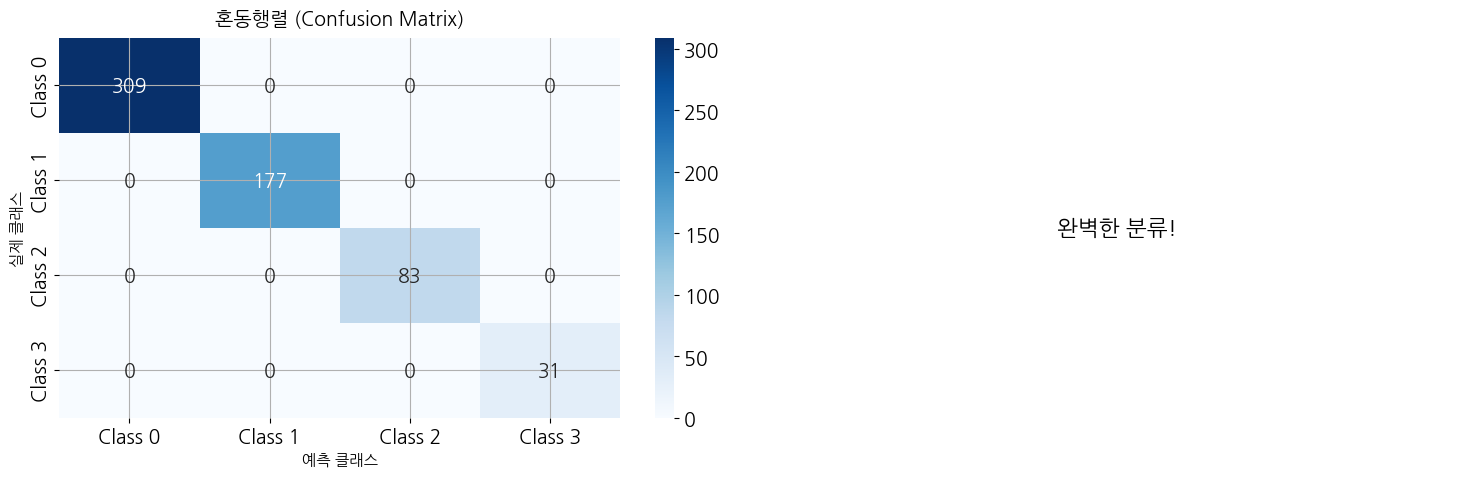


2. 상세 지표


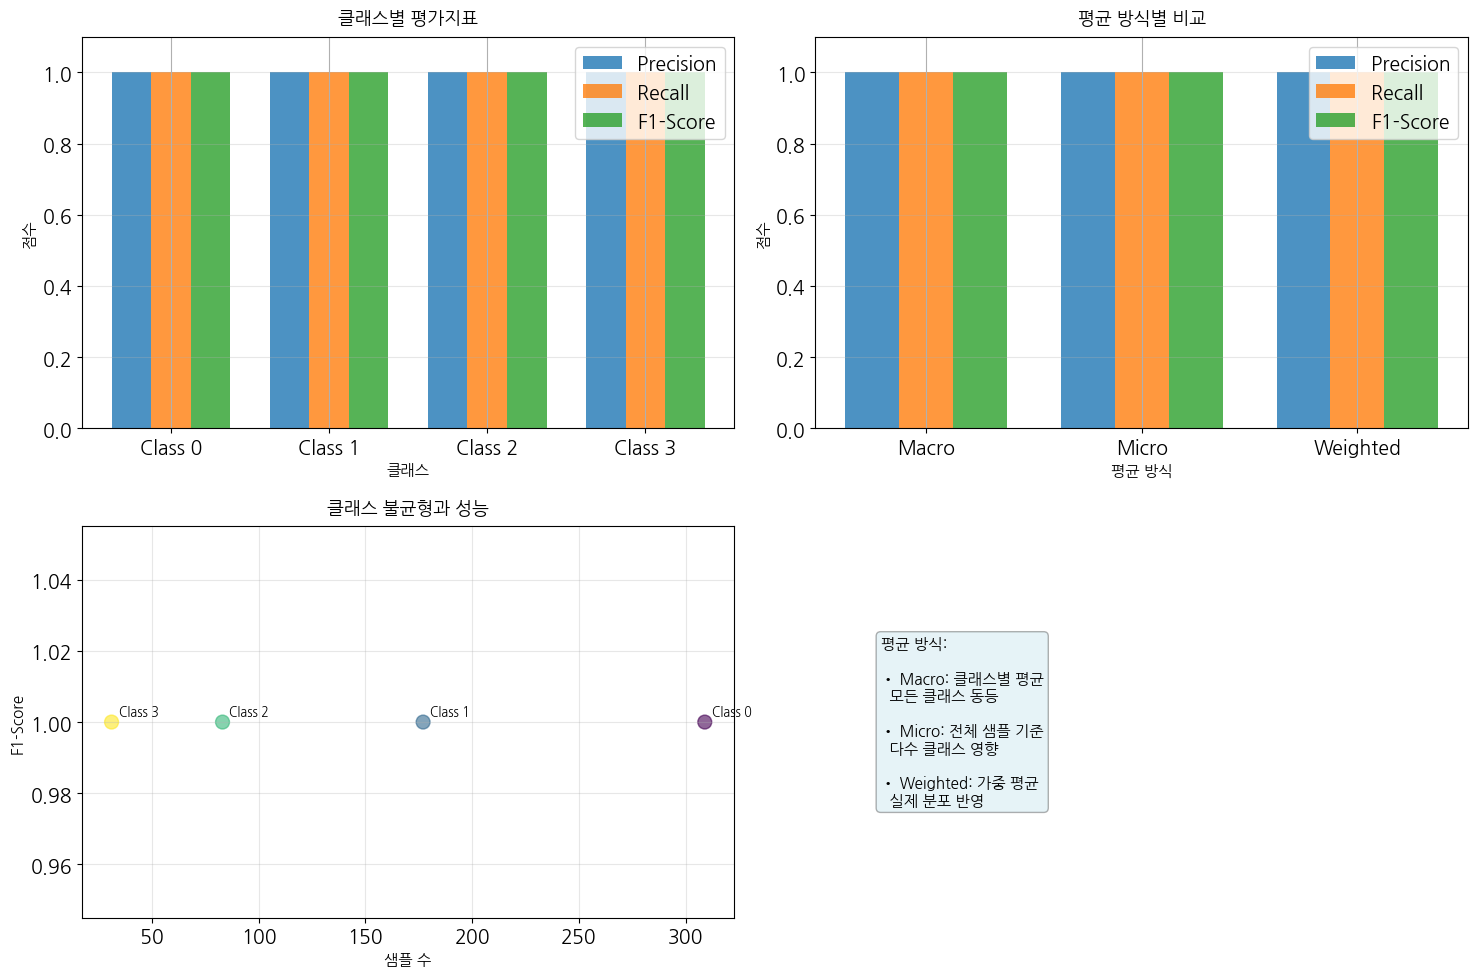


분류 리포트
              precision    recall  f1-score   support

     Class 0      1.000     1.000     1.000       309
     Class 1      1.000     1.000     1.000       177
     Class 2      1.000     1.000     1.000        83
     Class 3      1.000     1.000     1.000        31

    accuracy                          1.000       600
   macro avg      1.000     1.000     1.000       600
weighted avg      1.000     1.000     1.000       600


3. ROC-AUC


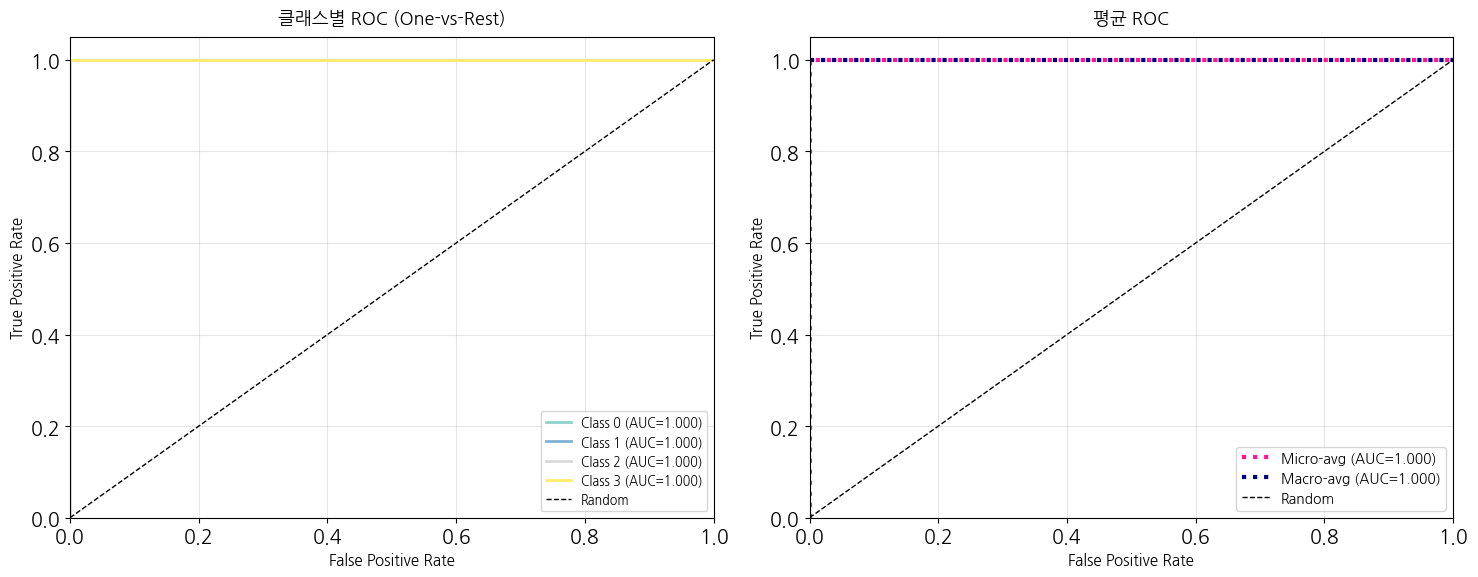


ROC-AUC 점수
Class 0        : 1.0000
Class 1        : 1.0000
Class 2        : 1.0000
Class 3        : 1.0000
Micro-avg      : 1.0000
Macro-avg      : 1.0000

방법 2: Oversampling

[학습 시작]
Epoch [10/30], Loss: 0.0195
Epoch [20/30], Loss: 0.0084
Epoch [30/30], Loss: 0.0042

[평가]

혼동행렬


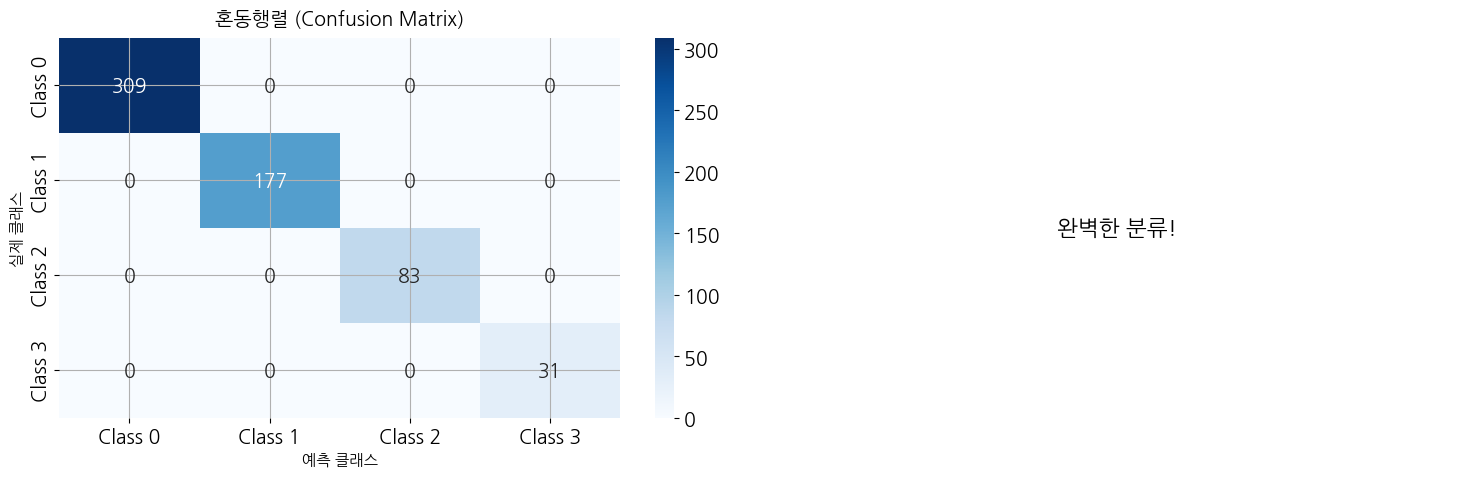


방법 3: Data Augmentation

증강 후 데이터 크기: 2100 (원본: 1400)

[학습 시작]
Epoch [10/30], Loss: 0.0111
Epoch [20/30], Loss: 0.0041
Epoch [30/30], Loss: 0.0018

[평가]

혼동행렬


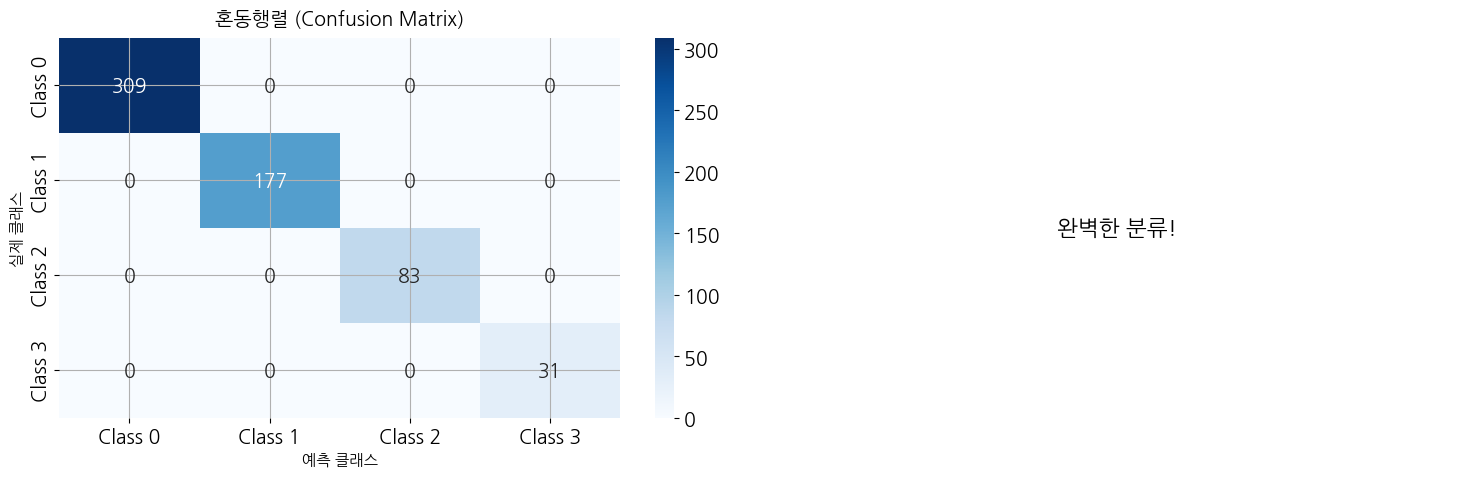


4. Temperature Scaling
온도 스케일링 완료: T = 1.299


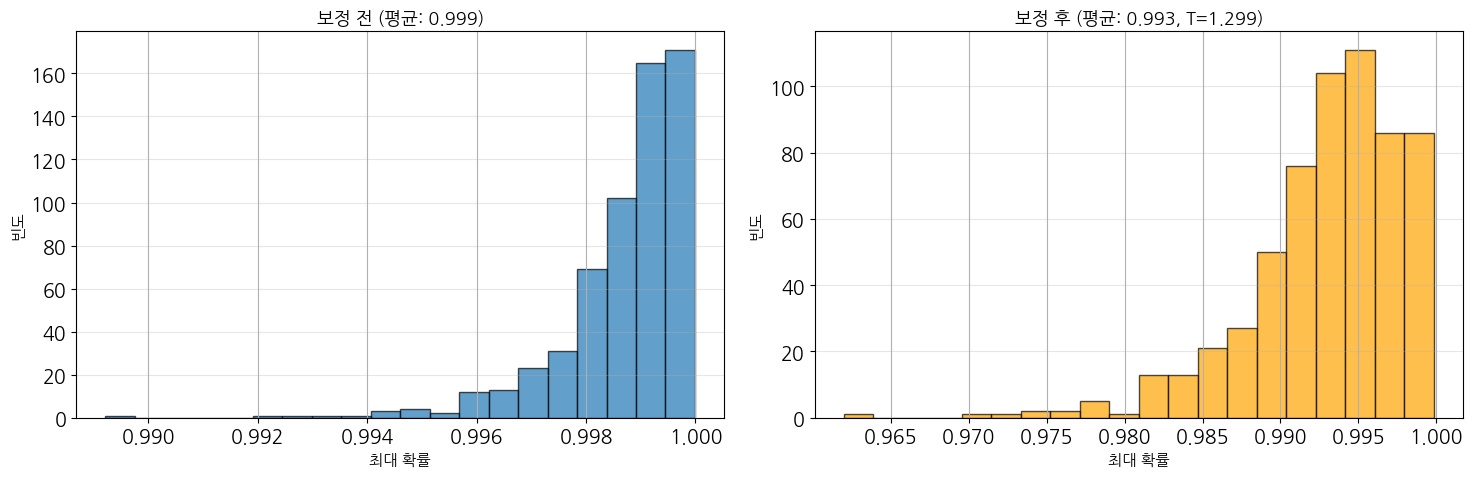


5. 방법 비교


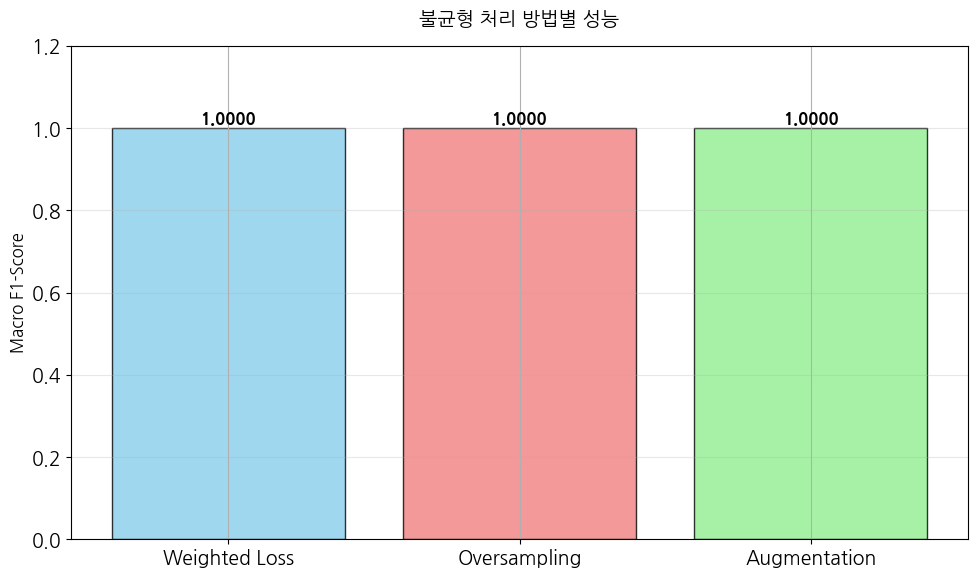


최종 비교:
  Weighted Loss       : 1.0000
  Oversampling        : 1.0000
  Augmentation        : 1.0000

강의 완료! 🎓


In [34]:
# ===================================================================
# 9. 메인 실행
# ===================================================================
def main():
    print("="*70)
    print("10차수: 고급 평가지표 및 클래스 불균형 처리")
    print("="*70)


    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n디바이스: {device}")


    # 데이터 생성
    full_dataset = ImbalancedDataset(
        n_samples=2000, n_features=20, n_classes=4,
        imbalance_ratio=[0.5, 0.3, 0.15, 0.05]
    )


    # 분할
    train_size = int(0.7 * len(full_dataset))
    test_size = len(full_dataset) - train_size
    train_dataset, test_dataset = torch.utils.data.random_split(
        full_dataset, [train_size, test_size],
        generator=torch.Generator().manual_seed(42)
    )


    class_names = ['Class 0', 'Class 1', 'Class 2', 'Class 3']
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


    # ===============================================================
    # 방법 1: Weighted Loss
    # ===============================================================
    print("\n" + "="*70)
    print("방법 1: Weighted Loss")
    print("="*70)


    train_loader_normal = DataLoader(train_dataset, batch_size=64, shuffle=True)
    class_weights = get_class_weights(train_loader_normal, n_classes=4).to(device)


    model1 = MultiClassClassifier(20, 64, 4).to(device)
    criterion_weighted = nn.CrossEntropyLoss(weight=class_weights)
    optimizer1 = torch.optim.Adam(model1.parameters(), lr=0.001)


    print("\n[학습 시작]")
    train_model(model1, train_loader_normal, criterion_weighted, optimizer1, device, 30)


    print("\n[평가]")
    y_true, y_pred, y_proba = evaluate_model(model1, test_loader, device)


    print("\n1. 혼동행렬")
    plot_confusion_matrix_with_analysis(y_true, y_pred, class_names)


    print("\n2. 상세 지표")
    calculate_detailed_metrics(y_true, y_pred, y_proba, class_names)


    print("\n3. ROC-AUC")
    plot_roc_curves_multiclass(y_true, y_proba, class_names)


    # ===============================================================
    # 방법 2: Oversampling
    # ===============================================================
    print("\n" + "="*70)
    print("방법 2: Oversampling")
    print("="*70)


    # 먼저 일반 loader로 레이블 수집 후 sampler 생성
    temp_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
    sampler = create_weighted_sampler(temp_loader)
    train_loader_oversampled = DataLoader(train_dataset, batch_size=64, sampler=sampler)


    model2 = MultiClassClassifier(20, 64, 4).to(device)
    criterion_normal = nn.CrossEntropyLoss()
    optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)


    print("\n[학습 시작]")
    train_model(model2, train_loader_oversampled, criterion_normal, optimizer2, device, 30)


    print("\n[평가]")
    y_true2, y_pred2, y_proba2 = evaluate_model(model2, test_loader, device)


    print("\n혼동행렬")
    plot_confusion_matrix_with_analysis(y_true2, y_pred2, class_names)


    # ===============================================================
    # 방법 3: Data Augmentation
    # ===============================================================
    print("\n" + "="*70)
    print("방법 3: Data Augmentation")
    print("="*70)


    augmented_dataset = AugmentedWrapper(train_dataset, augment_ratio=0.5, noise_std=0.15)
    train_loader_augmented = DataLoader(augmented_dataset, batch_size=64, shuffle=True)


    model3 = MultiClassClassifier(20, 64, 4).to(device)
    optimizer3 = torch.optim.Adam(model3.parameters(), lr=0.001)


    print(f"\n증강 후 데이터 크기: {len(augmented_dataset)} (원본: {len(train_dataset)})")
    print("\n[학습 시작]")
    train_model(model3, train_loader_augmented, criterion_normal, optimizer3, device, 30)


    print("\n[평가]")
    y_true3, y_pred3, y_proba3 = evaluate_model(model3, test_loader, device)


    print("\n혼동행렬")
    plot_confusion_matrix_with_analysis(y_true3, y_pred3, class_names)


    # ===============================================================
    # 4. Temperature Scaling
    # ===============================================================
    print("\n" + "="*70)
    print("4. Temperature Scaling")
    print("="*70)


    temp_scaler = TemperatureScaling().to(device)
    temperature = temp_scaler.calibrate(model1, test_loader, device)


    model1.eval()
    all_probs_before = []
    all_probs_after = []


    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            logits = model1(inputs)


            probs_before = F.softmax(logits, dim=1)
            probs_after = F.softmax(temp_scaler(logits), dim=1)


            all_probs_before.extend(probs_before.cpu().numpy().tolist())
            all_probs_after.extend(probs_after.cpu().numpy().tolist())


    all_probs_before = np.array(all_probs_before)
    all_probs_after = np.array(all_probs_after)


    fig, axes = plt.subplots(1, 2, figsize=(15, 5))


    max_probs_before = all_probs_before.max(axis=1)
    max_probs_after = all_probs_after.max(axis=1)


    axes[0].hist(max_probs_before, bins=20, alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('최대 확률', fontsize=11)
    axes[0].set_ylabel('빈도', fontsize=11)
    axes[0].set_title(f'보정 전 (평균: {max_probs_before.mean():.3f})', fontsize=13)
    axes[0].grid(axis='y', alpha=0.3)


    axes[1].hist(max_probs_after, bins=20, alpha=0.7, edgecolor='black', color='orange')
    axes[1].set_xlabel('최대 확률', fontsize=11)
    axes[1].set_ylabel('빈도', fontsize=11)
    axes[1].set_title(f'보정 후 (평균: {max_probs_after.mean():.3f}, T={temperature:.3f})', fontsize=13)
    axes[1].grid(axis='y', alpha=0.3)


    plt.tight_layout()
    plt.show()

    # ===============================================================
    # 5. 방법 비교
    # ===============================================================
    print("\n" + "="*70)
    print("5. 방법 비교")
    print("="*70)


    _, _, f1_1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    _, _, f1_2, _ = precision_recall_fscore_support(y_true2, y_pred2, average='macro', zero_division=0)
    _, _, f1_3, _ = precision_recall_fscore_support(y_true3, y_pred3, average='macro', zero_division=0)


    methods = ['Weighted Loss', 'Oversampling', 'Augmentation']
    scores = [f1_1, f1_2, f1_3]


    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(methods, scores, color=['skyblue', 'lightcoral', 'lightgreen'],
                  edgecolor='black', alpha=0.8)


    for bar, score in zip(bars, scores):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{score:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')


    ax.set_ylabel('Macro F1-Score', fontsize=12)
    ax.set_title('불균형 처리 방법별 성능', fontsize=14, pad=15)
    ax.set_ylim([0, max(scores) * 1.2])
    ax.grid(axis='y', alpha=0.3)


    plt.tight_layout()
    plt.show()


    print("\n최종 비교:")
    for method, score in zip(methods, scores):
        print(f"  {method:20s}: {score:.4f}")


    print("\n" + "="*70)
    print("강의 완료! 🎓")
    print("="*70)


if __name__ == "__main__":
    main()
